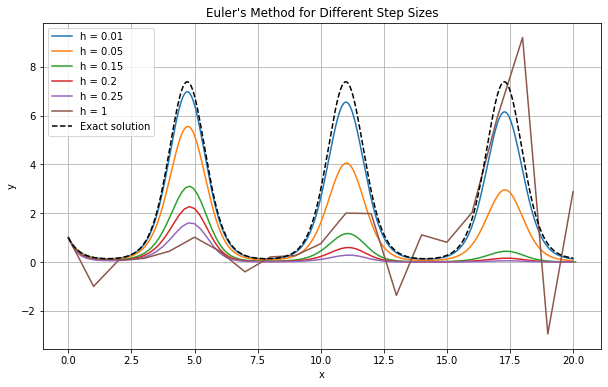

h = 0.01
  average y-value = 1.930801
  average error   = 0.239711
  local error near x=15 = 0.040935
  y near x=15 = 0.231440
  exact at x=15.00 = 0.272375

h = 0.05
  average y-value = 1.241112
  average error   = 0.927249
  local error near x=15 = 0.152506
  y near x=15 = 0.119869
  exact at x=15.00 = 0.272375

h = 0.15
  average y-value = 0.476816
  average error   = 1.673878
  local error near x=15 = 0.251454
  y near x=15 = 0.020921
  exact at x=15.00 = 0.272375

h = 0.2
  average y-value = 0.315091
  average error   = 1.841768
  local error near x=15 = 0.264472
  y near x=15 = 0.007903
  exact at x=15.00 = 0.272375

h = 0.25
  average y-value = 0.211108
  average error   = 1.942031
  local error near x=15 = 0.269713
  y near x=15 = 0.002662
  exact at x=15.00 = 0.272375

h = 1
  average y-value = 1.171413
  average error   = 1.816062
  local error near x=15 = 0.536218
  y near x=15 = 0.808593
  exact at x=15.00 = 0.272375



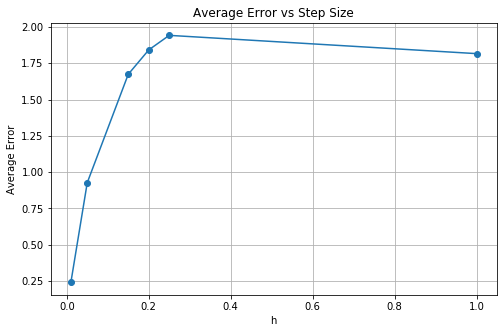

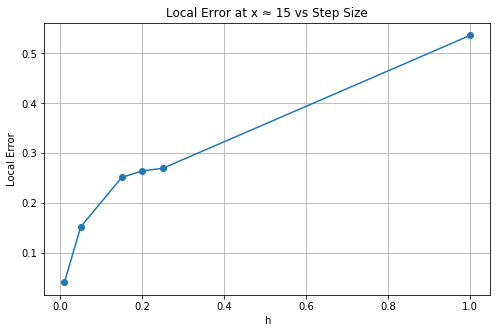

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# differential equation
def f(x, y):
    return -2 * y * np.cos(x)

# exact solution
def exact_solution(x):
    return np.exp(-2 * np.sin(x))

# Euler method
def euler(h, x0, xf, y0):
    x_vals = np.arange(x0, xf + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = y0

    for i in range(len(x_vals) - 1):
        # just doing Euler's formula straight up
        y_vals[i + 1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    return x_vals, y_vals


h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 1]
x0, xf, y0 = 0, 20, 1

all_runs = {}
avg_y_values = []
avg_errors = []
local_errors = []

# first get all Euler runs
for h in h_values:
    x_vals, y_vals = euler(h, x0, xf, y0)
    all_runs[h] = (x_vals, y_vals)

# use h = 0.01 as the "reference" run for comparing between runs
x_ref, y_ref = all_runs[0.01]

# Plot 1: compare Euler runs
plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals, y_vals = all_runs[h]
    plt.plot(x_vals, y_vals, label=f"h = {h}")

# exact solution too so we can see what's going on
x_exact = np.linspace(x0, xf, 1000)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, "k--", label="Exact solution")

plt.title("Euler's Method for Different Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# calculate averages/errors
for h in h_values:
    x_vals, y_vals = all_runs[h]

    # exact solution at the SAME x points as this run
    y_true = exact_solution(x_vals)

    # average of the y-values for this run
    avg_y = np.mean(y_vals)
    avg_y_values.append(avg_y)

    # average error for this run compared to exact solution
    error = np.abs(y_vals - y_true)
    avg_error = np.mean(error)
    avg_errors.append(avg_error)

    # local error near x = 15
    idx_15 = np.argmin(np.abs(x_vals - 15))
    local_error = error[idx_15]
    local_errors.append(local_error)

    print(f"h = {h}")
    print(f"  average y-value = {avg_y:.6f}")
    print(f"  average error   = {avg_error:.6f}")
    print(f"  local error near x=15 = {local_error:.6f}")
    print(f"  y near x=15 = {y_vals[idx_15]:.6f}")
    print(f"  exact at x={x_vals[idx_15]:.2f} = {y_true[idx_15]:.6f}")
    print()

# Plot 2: average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.title("Average Error vs Step Size")
plt.xlabel("h")
plt.ylabel("Average Error")
plt.grid(True)
plt.show()

# Plot 3: local error near x = 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.title("Local Error at x ≈ 15 vs Step Size")
plt.xlabel("h")
plt.ylabel("Local Error")
plt.grid(True)
plt.show()

Overall, the results show that the step size h has a strong effect on the accuracy of Euler’s method. When h is small, the numerical solution closely follows the exact solution, and both the average and local errors are small. As h increases, the solution becomes less accurate and deviates more. This happens because Euler’s method approximates the solution using linear steps, so larger step sizes introduce more accumulated error. The plots confirm that decreasing h improves accuracy, which is consistent with the behavior of first-order methods.


In [7]:
# part 2: Stability Analysis


print("Stability Analysis")

# cos(x) always stays between -1 and 1
# so lambda(x) = -2cos(x) stays between -2 and 2
lambda_min = -2
lambda_max = 2

print(f"lambda(x) ranges from {lambda_min} to {lambda_max}")

# for Forward Euler, the standard stability condition for y' = lambda y is:
# |1 + h*lambda| <= 1

# worst case here:
# lambda = -2

# then:
# |1 - 2h| <= 1
# this is after solving basically 0 <= h <= 1

h_stable_max = 1

print("For y' = lambda y, Forward Euler is stable when |1 + h*lambda| <= 1.")
print("Here lambda(x) = -2 cos(x), so it changes with x.")
print("In the regions where cos(x) > 0, lambda(x) < 0, and the worst case is lambda = -2.")
print("That gives |1 - 2h| <= 1, so in those regions we need 0 <= h <= 1.")
print("So h <= 1 is a local stability condition for the decaying part of the solution.")

# check the h values we used
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 1]

print("\nChecking our step sizes:")
for h in h_values:
    if h <= h_stable_max:
        print(f"h = {h} -> satisfies the stability condition")
    else:
        print(f"h = {h} -> does not satisfy the stability condition")

Stability Analysis
lambda(x) ranges from -2 to 2
For y' = lambda y, Forward Euler is stable when |1 + h*lambda| <= 1.
Here lambda(x) = -2 cos(x), so it changes with x.
In the regions where cos(x) > 0, lambda(x) < 0, and the worst case is lambda = -2.
That gives |1 - 2h| <= 1, so in those regions we need 0 <= h <= 1.
So h <= 1 is a local stability condition for the decaying part of the solution.

Checking our step sizes:
h = 0.01 -> satisfies the stability condition
h = 0.05 -> satisfies the stability condition
h = 0.15 -> satisfies the stability condition
h = 0.2 -> satisfies the stability condition
h = 0.25 -> satisfies the stability condition
h = 1 -> satisfies the stability condition


We can rewrite the equation as a form where the growth rate depends on x, meaning the effective “lambda” is negative two times cosine of x. Since cosine of x is always between negative one and one, this means lambda stays between negative two and positive two.

For Forward Euler, the stability condition says the step size times lambda must stay within a certain range so the solution does not blow up. The worst case happens when lambda is most negative, which is negative two. Using that case, we find that the step size must be less than or equal to one.

So, Forward Euler is only stable when the step size is at most one. Even though all our step sizes satisfy this, the larger ones are close to the limit, which is why they are much less accurate and start to drift in the plots.